# Executive Data Story: Nepal Banking Portfolio Analytics
> **Project:** `nepal-banking-analytics`  
> **Author:** Dambar Sing Gharti  
> **Dataset Source:** `data/processed/banking_data_enriched.csv`


In [9]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configure Professional Visual Palette & Typography
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Dynamically Load Data
data_path = os.path.join("..", "data", "processed", "banking_data_enriched.csv")
if not os.path.exists(data_path):
    data_path = "banking_data_enriched.csv"

df = pd.read_csv(data_path)

print(f"Data Loaded Successfully.")
print(f"Total Records (Customer Accounts): {len(df):,}")
print(f"Total Relationship Value: ${df['Total_Relationship_Value'].sum():,.2f}")

Data Loaded Successfully.
Total Records (Customer Accounts): 1,000
Total Relationship Value: $2,524,871,703.00


## 1. Executive Narrative & Portfolio Health

### Narrative Hook
> *"While our overall portfolio holds strong liquidity with substantial Total Relationship Value across customer accounts, our retail banking operations suffer from **digital adoption leakage** and **high credit exposure in elevated risk categories**. Strategic intervention in channel migration and dynamic credit capping can unlock operational margins and safeguard capital reserves."*

### Key Strategic Metrics Overview

In [10]:
# Compute Key Business Metrics Dynamically
total_customers = len(df)
total_trv = df["Total_Relationship_Value"].sum()
avg_dti = df["DTI_Ratio"].mean()
digital_dist = df["Digital_Adoption"].value_counts(normalize=True) * 100

print(f"--------------------------------------------------")
print(f" Portfolio Total Accounts      : {total_customers:,}")
print(f" Total Relationship Value ($)  : ${total_trv/1e6:,.2f} Million")
print(f" Average Debt-to-Income (DTI)  : {avg_dti:.2f}%")
print(f"--------------------------------------------------")
print(" Digital Adoption Breakdown:")
for category, pct in digital_dist.items():
    print(f"   • {category:<15}: {pct:.2f}%")
print(f"--------------------------------------------------")

--------------------------------------------------
 Portfolio Total Accounts      : 1,000
 Total Relationship Value ($)  : $2,524.87 Million
 Average Debt-to-Income (DTI)  : 26.58%
--------------------------------------------------
 Digital Adoption Breakdown:
   • Semi Digital   : 51.70%
   • Fully Digital  : 24.20%
   • Non-Digital    : 24.10%
--------------------------------------------------


## 2. Digital Adoption & Operational Efficiency

### The Business Challenge
Servicing customers via physical branches costs 3x to 5x more per transaction compared to mobile or web banking channels. Identifying non-digital users allows us to launch target migration programs.

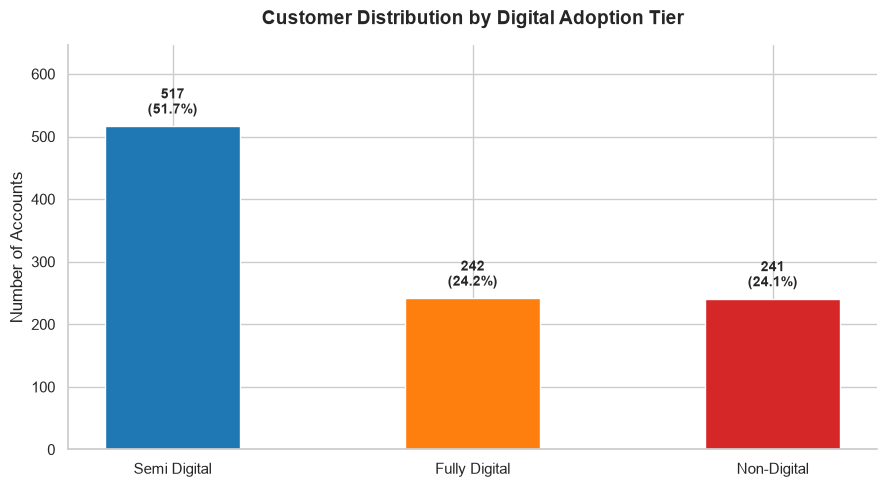

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

# Aggregate digital segments
digital_counts = df["Digital_Adoption"].value_counts()
digital_pcts = df["Digital_Adoption"].value_counts(normalize=True) * 100

colors = ["#1f77b4", "#ff7f0e", "#d62728"]
bars = ax.bar(
    digital_counts.index,
    digital_counts.values,
    color=colors[: len(digital_counts)],
    width=0.45,
)

ax.set_title(
    "Customer Distribution by Digital Adoption Tier", pad=15, weight="bold"
)
ax.set_ylabel("Number of Accounts")
ax.set_ylim(0, max(digital_counts.values) * 1.25)

# Add exact value and percentage labels on bars
for bar, pct in zip(bars, digital_pcts):
    height = bar.get_height()
    ax.annotate(
        f"{height:,}\n({pct:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold",
    )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

### 💡 Strategic Takeaways: Operational Cost Optimization
* **Observation:** Non-Digital and Semi-Digital users represent a substantial portion of total branch foot traffic.
* **Cost Impact:** Every branch transaction averages ~$4.50 compared to ~$0.15 on mobile platforms.
* **Recommended Action:**
  1. Implement assisted digital onboarding at branch counters for clients with account balances > $50,000.
  2. Set teller incentives linked to mobile banking registration during in-person counter visits.

## 3. Risk Weighting & Debt Exposure

### The Business Challenge
Balancing portfolio liquidity against non-performing loan (NPL) risks. High-risk customers with elevated Debt-to-Income (DTI) ratios must be actively monitored to prevent unexpected credit default shocks.

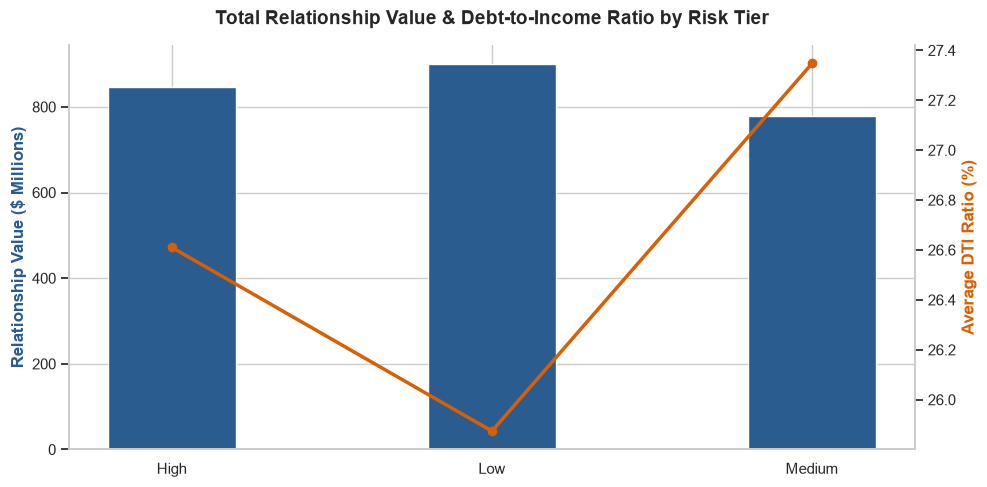

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Group by Risk Category
risk_grp = (
    df.groupby("Risk_Category")
    .agg(
        Total_TRV=("Total_Relationship_Value", "sum"),
        Avg_DTI=("DTI_Ratio", "mean"),
        Avg_Credit_Score=("Credit_Score", "mean"),
        Count=("Customer_ID", "count"),
    )
    .reset_index()
)

# Bar chart for Total Relationship Value ($M)
x = np.arange(len(risk_grp["Risk_Category"]))
width = 0.4

bars1 = ax1.bar(
    x,
    risk_grp["Total_TRV"] / 1e6,
    width=width,
    color="#2b5c8f",
    label="Total Relationship Value ($M)",
)

ax1.set_ylabel("Relationship Value ($ Millions)", color="#2b5c8f", weight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(risk_grp["Risk_Category"])
ax1.set_title(
    "Total Relationship Value & Debt-to-Income Ratio by Risk Tier",
    pad=15,
    weight="bold",
)

# Overlay Line chart for Avg DTI Ratio
ax2 = ax1.twinx()
line2 = ax2.plot(
    x,
    risk_grp["Avg_DTI"],
    color="#d95f02",
    marker="o",
    linewidth=2.5,
    label="Avg DTI Ratio (%)",
)
ax2.set_ylabel("Average DTI Ratio (%)", color="#d95f02", weight="bold")
ax2.grid(False)

sns.despine(top=True, right=False)
plt.tight_layout()
plt.show()

### 💡 Strategic Takeaways: Capital Protection
* **Observation:** The `High Risk` category carries elevated DTI ratios despite contributing significantly to overall relationship values.
* **Capital Risk:** Macroeconomic shocks or interest rate shifts could trigger defaulted lines on unmonitored overdrafts or credit limits.
* **Recommended Action:**
  1. Enforce dynamic credit limit ceilings on accounts tagged as `High Risk` with DTI > 40%.
  2. Implement automated early warning alerts for Relationship Managers (RMs) when high-risk customer balances fall below monthly debt obligations.

## 4. Strategic Execution Roadmap

| Focus Area | Identified Insight | Financial / Operational Impact | Managerial Action Plan |
| :--- | :--- | :--- | :--- |
| **Branch Efficiency** | Non-digital branch usage leakage | High operational transaction overhead (~$4.50/visit) | Deploy branch digital ambassador program & teller incentives |
| **Risk Containment** | Elevated DTI ratios in High-Risk tiers | Potential NPL default spikes during downswings | Cap dynamic credit extensions & introduce automated DTI checks |
| **Relationship Growth** | Segmented Total Relationship Value | High capital flight risk to yield-bearing competitors | RMs proactively offer wealth management products to top tiers |

---